# Generic Pipeline

In [ ]:
import os
import warnings
import logging

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from pykrige.ok import OrdinaryKriging

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
)
log = logging.getLogger("StationPipeline")

# Kriging models using
KRIGING_MODELS = ["linear", "spherical", "exponential",  "gaussian"]

# ─────────────────────────────────────────────────────────────────────────────
class StationInterpolationPipeline:

    def __init__(
        self,
        excel_path:  str,
        lat_col:     str,
        lon_col:     str,
        value_col:   str,
        date_col:    str,
        era5_nc_path: str,
        era5_var:    str,
        output_dir:  str = "station_output",
        plot_date:   str = None,
    ):
        self.excel_path   = excel_path
        self.lat_col      = lat_col
        self.lon_col      = lon_col
        self.value_col    = value_col
        self.date_col     = date_col
        self.era5_nc_path = era5_nc_path
        self.era5_var     = era5_var
        self.output_dir   = output_dir
        self.plot_date    = plot_date

        os.makedirs(output_dir, exist_ok=True)

        self.df          = None
        self.era5_ds     = None
        self.lat_grid    = None
        self.lon_grid    = None
        self.GRID_LON    = None
        self.GRID_LAT    = None
        self.shared_dates = None

    # ── Step 1 – Load (called once) ───────────────────────────────────
    def load_data(self):
        """Load station Excel and ERA5; extract shared grid and dates."""
        log.info("Loading station data …")
        self.df = pd.read_excel(self.excel_path)
        self.df[self.date_col] = pd.to_datetime(self.df[self.date_col])
        self.df = self.df.dropna(
            subset=[self.lat_col, self.lon_col, self.value_col, self.date_col]
        )

        log.info("Loading ERA5 …")
        self.era5_ds  = xr.open_dataset(self.era5_nc_path, chunks={"time": 30})
        self.lat_grid = self.era5_ds["lat"].values
        self.lon_grid = self.era5_ds["lon"].values
        self.GRID_LON, self.GRID_LAT = np.meshgrid(self.lon_grid, self.lat_grid)

        # Shared dates (intersection)
        station_dates = set(self.df[self.date_col].dt.normalize().unique())
        era5_dates    = set(pd.to_datetime(self.era5_ds["time"].values).normalize())
        self.shared_dates = sorted(station_dates & era5_dates)

        if not self.shared_dates:
            raise ValueError("No overlapping dates between station data and ERA5.")

        # Resolve plot date
        if self.plot_date is None:
            self.plot_date = self.shared_dates[0]
            log.info("plot_date not set → using first shared date: %s",
                     pd.Timestamp(self.plot_date).date())
        else:
            self.plot_date = pd.Timestamp(self.plot_date).normalize()

        num_unique_stations = len(self.df[[self.lat_col, self.lon_col]].drop_duplicates())
        log.info(
            "Unique_stations=%d  |  Shared dates=%d  (%s → %s)",
            num_unique_stations,
            len(self.shared_dates),
            self.shared_dates[0].date(),
            self.shared_dates[-1].date(),
        )

    # ── Internal – kriging one date ────────────────────────────────────
    def _kriging_one_date(self, date: pd.Timestamp, model: str) -> np.ndarray:
        df_day = self.df[self.df[self.date_col].dt.normalize() == date.normalize()]
        if df_day.empty:
            return np.full(self.GRID_LON.shape, np.nan)

        OK = OrdinaryKriging(
            df_day[self.lon_col].values,
            df_day[self.lat_col].values,
            df_day[self.value_col].values,
            variogram_model=model,
            verbose=False,
            enable_plotting=False,
        )
        grid_vals, _ = OK.execute("grid", self.lon_grid, self.lat_grid)
        return np.array(grid_vals)

    # ── Step 2 – Metrics for one model ────────────────────────────────
    def _compute_metrics(self, model: str) -> dict:

        log.info("  Computing metrics for model: %s", model)

        rows        = []
        grids       = []   # accumulate (lat, lon) arrays for every date
        valid_times = []   # matching timestamps

        for date in self.shared_dates:
            ts = pd.Timestamp(date)

            station_grid = self._kriging_one_date(ts, model)
            era5_slice   = (
                self.era5_ds[self.era5_var]
                .sel(time=ts, method="nearest")
                .values
            )

            # Always accumulate – even if some pixels are NaN
            grids.append(station_grid)
            valid_times.append(ts)

            mask = ~(np.isnan(era5_slice) | np.isnan(station_grid))
            if mask.sum() == 0:
                continue

            e = era5_slice[mask]
            s = station_grid[mask]
            r, _ = pearsonr(e, s)

            rows.append({
                "RMSE":      float(np.sqrt(mean_squared_error(e, s))),
                "MAE":       float(np.mean(np.abs(e - s))),
                "Bias":      float(np.mean(s - e)),
                "Pearson_r": float(r),
            })

        # ── Save interpolated grids as NetCDF ─────────────────────────
        interp_array = np.stack(grids, axis=0)   # (time, lat, lon)
        interp_da = xr.DataArray(
            interp_array,
            dims=["time", "lat", "lon"],
            coords={
                "time": valid_times,
                "lat":  self.lat_grid,
                "lon":  self.lon_grid,
            },
            name=self.value_col,
            attrs={
                "interpolation_method": f"Ordinary Kriging – {model}",
                "source_excel":         self.excel_path,
                "era5_grid_reference":  self.era5_nc_path,
                "units":                "same as source variable",
            },
        )
        nc_path = os.path.join(
            self.output_dir, f"interpolated_kriging_{model}.nc"
        )
        interp_da.to_netcdf(nc_path)
        log.info("  Interpolated NetCDF saved → %s", nc_path)

        df_m  = pd.DataFrame(rows)
        means = df_m.mean().round(4).to_dict()
        means["model"] = model
        return means

    # ── Step 3 – Plot for one model ────────────────────────────────────
    def _plot(self, model: str, mean_metrics: dict):
        """Two-panel plot: station interpolation | ERA5 for plot_date."""
        ts = pd.Timestamp(self.plot_date)

        station_grid = self._kriging_one_date(ts, model)
        station_da   = xr.DataArray(
            station_grid,
            dims=["lat", "lon"],
            coords={"lat": self.lat_grid, "lon": self.lon_grid},
        )
        era5_slice = (
            self.era5_ds[self.era5_var]
            .sel(time=ts, method="nearest")
        )

        vmin = min(np.nanmin(station_grid), float(era5_slice.min()))
        vmax = max(np.nanmax(station_grid), float(era5_slice.max()))

        proj   = ccrs.PlateCarree()
        extent = [
            float(self.lon_grid.min()), float(self.lon_grid.max()),
            float(self.lat_grid.min()), float(self.lat_grid.max()),
        ]

        fig = plt.figure(figsize=(16, 6))
        gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.12)

        panels = [
            (station_da,
             f"Kriging ({model.capitalize()})  –  {self.value_col}\n{ts.date()}"),
            (era5_slice,
             f"ERA5  –  {self.era5_var}\n{ts.date()}"),
        ]

        for idx, (da, title) in enumerate(panels):
            ax = fig.add_subplot(gs[idx], projection=proj)
            da.plot(
                ax=ax, transform=proj, cmap="RdYlBu_r",
                vmin=vmin, vmax=vmax,
                cbar_kwargs={"shrink": 0.78, "pad": 0.04},
            )
            if idx == 0:
                df_day = self.df[
                    self.df[self.date_col].dt.normalize() == ts.normalize()
                ]
                ax.scatter(
                    df_day[self.lon_col], df_day[self.lat_col],
                    c="black", s=14, zorder=5, label="Stations",
                    transform=proj,
                )
                ax.legend(loc="lower right", fontsize=8)

            ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
            ax.add_feature(cfeature.BORDERS,   linestyle=":", linewidth=0.6)
            ax.add_feature(cfeature.STATES,    alpha=0.35, linewidth=0.4)
            ax.set_extent(extent, crs=proj)
            ax.set_title(title, fontsize=10, pad=6)

        # Footer – all-time mean metrics
        txt = (
            f"All-time mean  |  "
            f"RMSE={mean_metrics['RMSE']}   "
            f"MAE={mean_metrics['MAE']}   "
            f"Bias={mean_metrics['Bias']}   "
            f"r={mean_metrics['Pearson_r']}"
        )
        fig.text(
            0.5, -0.02, txt, ha="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"),
        )
        plt.suptitle(
            f"Station vs ERA5  |  Kriging – {model.capitalize()}  |  {self.value_col}",
            fontsize=13, y=0.85,
        )

        save_path = os.path.join(
            self.output_dir, f"plot_kriging_{model}_{ts.date()}.png"
        )
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        log.info("  Plot saved → %s", save_path)
        plt.show()
        plt.close()

    # ── run_all – main entry point ─────────────────────────────────────
    def run_all(self):

        self.load_data()

        summary_rows = []

        for model in KRIGING_MODELS:
            log.info("═══ Model: %s ═══════════════════════════════════", model.upper())
            means = self._compute_metrics(model)
            self._plot(model, means)
            summary_rows.append(means)
            log.info(
                "  RMSE=%.4f  MAE=%.4f  Bias=%.4f  r=%.4f",
                means["RMSE"], means["MAE"], means["Bias"], means["Pearson_r"],
            )

        # Final summary table
        summary_df = (
            pd.DataFrame(summary_rows)
            .set_index("model")
            [["RMSE", "MAE", "Bias", "Pearson_r"]]
        )

        csv_path = os.path.join(self.output_dir, "kriging_summary.csv")
        summary_df.to_csv(csv_path)

        log.info("\n── Kriging Summary (all-time means) ──────────────────")
        log.info("\n%s", summary_df.to_string())
        log.info("Summary saved → %s", csv_path)

        return summary_df

# AirTemperature

Loading station data …
Loading ERA5 …
Unique_stations=234  |  Shared dates=5844  (2006-01-01 → 2021-12-31)
═══ Model: LINEAR ═══════════════════════════════════
  Computing metrics for model: linear
  Interpolated NetCDF saved → temperature_interpolated_results\interpolated_kriging_linear.nc
  Plot saved → temperature_interpolated_results\plot_kriging_linear_2021-01-01.png


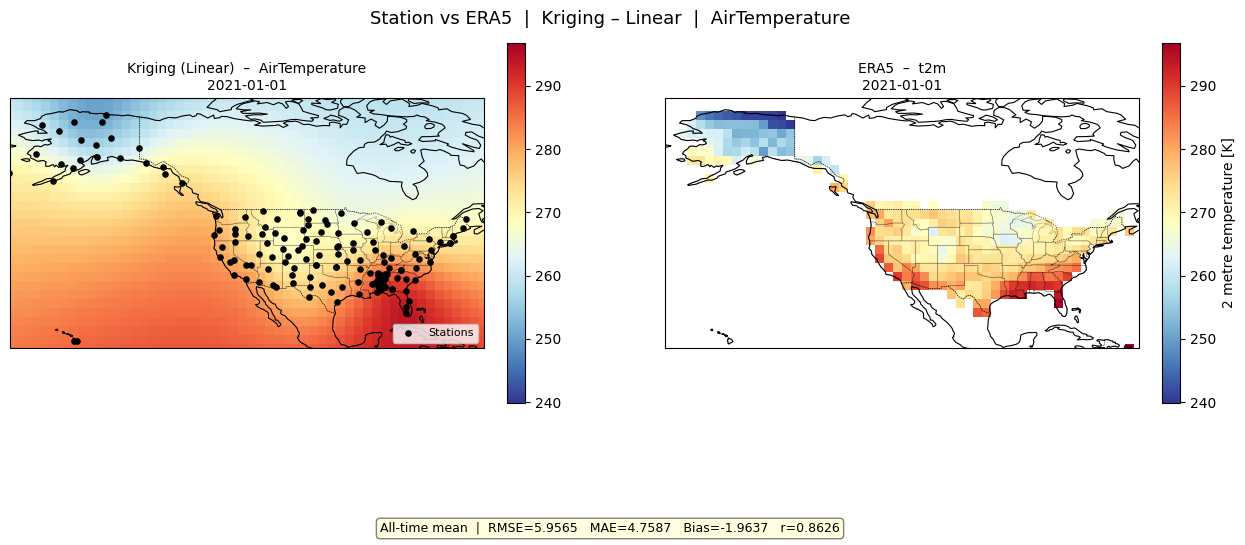

  RMSE=5.9565  MAE=4.7587  Bias=-1.9637  r=0.8626
═══ Model: SPHERICAL ═══════════════════════════════════
  Computing metrics for model: spherical
  Interpolated NetCDF saved → temperature_interpolated_results\interpolated_kriging_spherical.nc
  Plot saved → temperature_interpolated_results\plot_kriging_spherical_2021-01-01.png


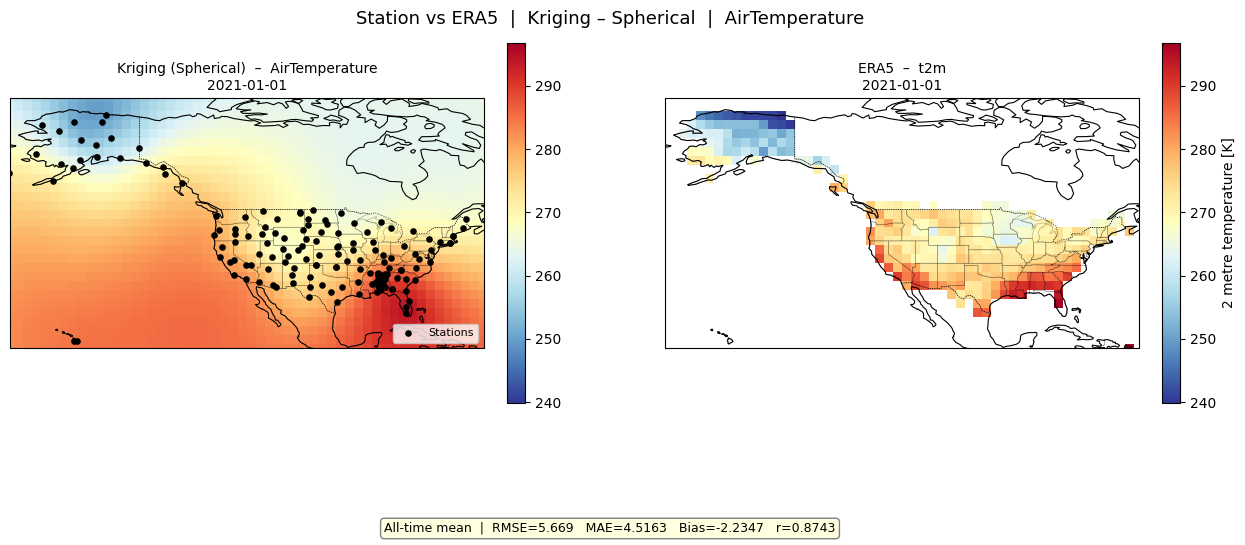

  RMSE=5.6690  MAE=4.5163  Bias=-2.2347  r=0.8743
═══ Model: EXPONENTIAL ═══════════════════════════════════
  Computing metrics for model: exponential
  Interpolated NetCDF saved → temperature_interpolated_results\interpolated_kriging_exponential.nc
  Plot saved → temperature_interpolated_results\plot_kriging_exponential_2021-01-01.png


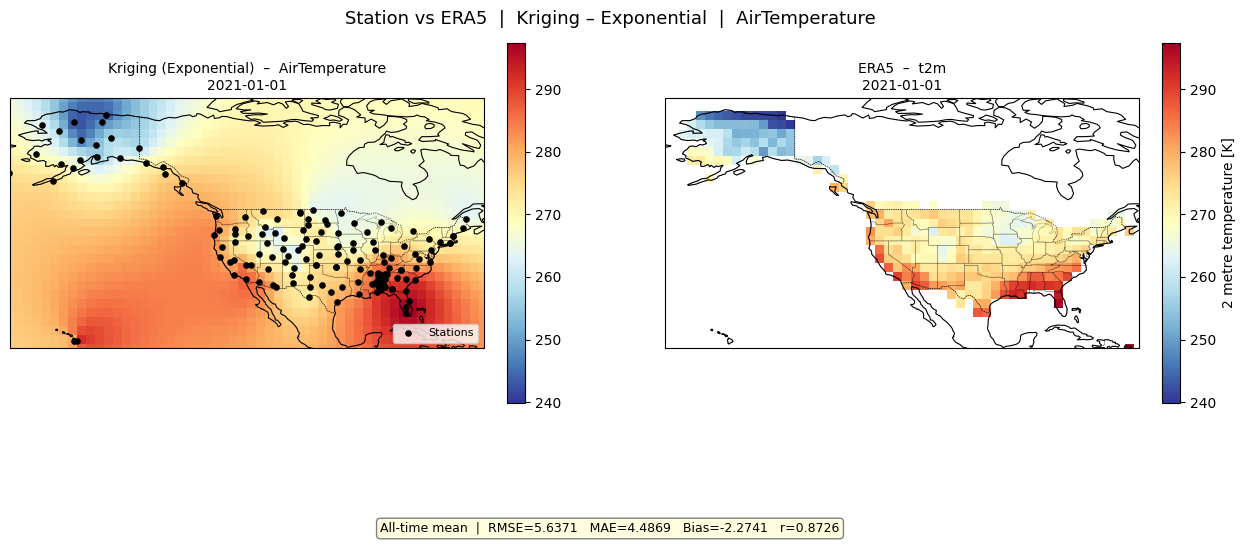

  RMSE=5.6371  MAE=4.4869  Bias=-2.2741  r=0.8726
═══ Model: GAUSSIAN ═══════════════════════════════════
  Computing metrics for model: gaussian
  Interpolated NetCDF saved → temperature_interpolated_results\interpolated_kriging_gaussian.nc
  Plot saved → temperature_interpolated_results\plot_kriging_gaussian_2021-01-01.png


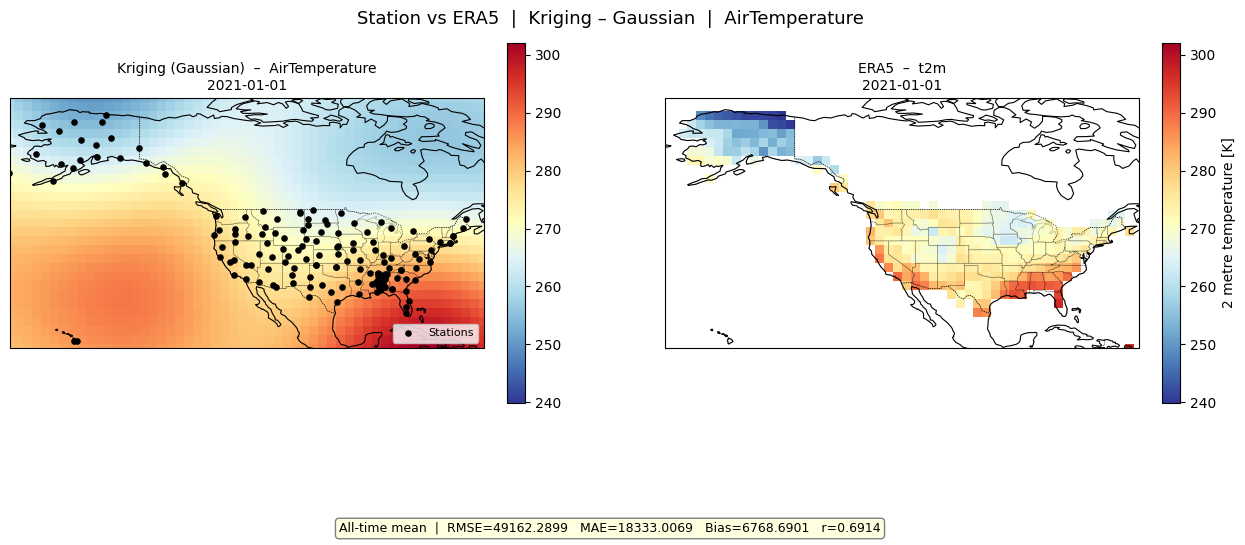

  RMSE=49162.2899  MAE=18333.0069  Bias=6768.6901  r=0.6914

── Kriging Summary (all-time means) ──────────────────

                   RMSE         MAE       Bias  Pearson_r
model                                                    
linear           5.9565      4.7587    -1.9637     0.8626
spherical        5.6690      4.5163    -2.2347     0.8743
exponential      5.6371      4.4869    -2.2741     0.8726
gaussian     49162.2899  18333.0069  6768.6901     0.6914
Summary saved → temperature_interpolated_results\kriging_summary.csv


In [ ]:
pipe = StationInterpolationPipeline(
    excel_path   = r"output_files\processed_USCRN_AirTemperature_2006_2021.xlsx",
    lat_col      = "Lat",
    lon_col      = "Lon",
    value_col    = "AirTemperature",
    date_col     = "date",
    era5_nc_path = r"era5_temperature\era5_clipped.nc",
    era5_var     = "t2m",
    output_dir   = "temperature_interpolated_results",
    plot_date    = "2021-01-01",
)

summary = pipe.run_all()

# Rainfall(ppt.)

Loading station data …
Loading ERA5 …
Unique_stations=234  |  Shared dates=5844  (2006-01-01 → 2021-12-31)
═══ Model: LINEAR ═══════════════════════════════════
  Computing metrics for model: linear
  Interpolated NetCDF saved → Precipitation_interpolated_results\interpolated_kriging_linear.nc
  Plot saved → Precipitation_interpolated_results\plot_kriging_linear_2021-01-01.png


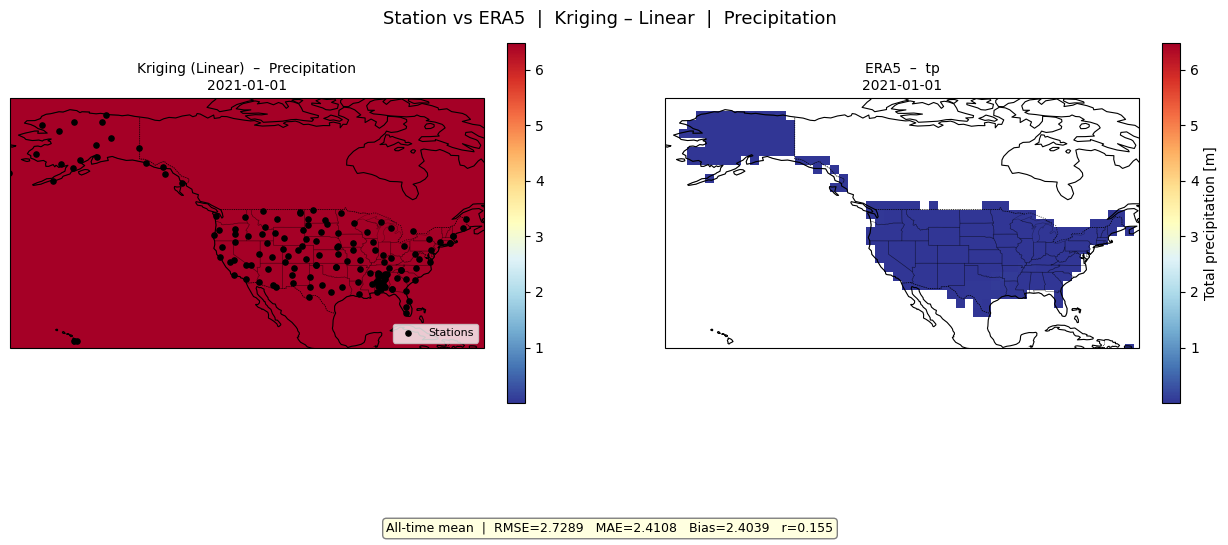

  RMSE=2.7289  MAE=2.4108  Bias=2.4039  r=0.1550
═══ Model: SPHERICAL ═══════════════════════════════════
  Computing metrics for model: spherical
  Interpolated NetCDF saved → Precipitation_interpolated_results\interpolated_kriging_spherical.nc
  Plot saved → Precipitation_interpolated_results\plot_kriging_spherical_2021-01-01.png


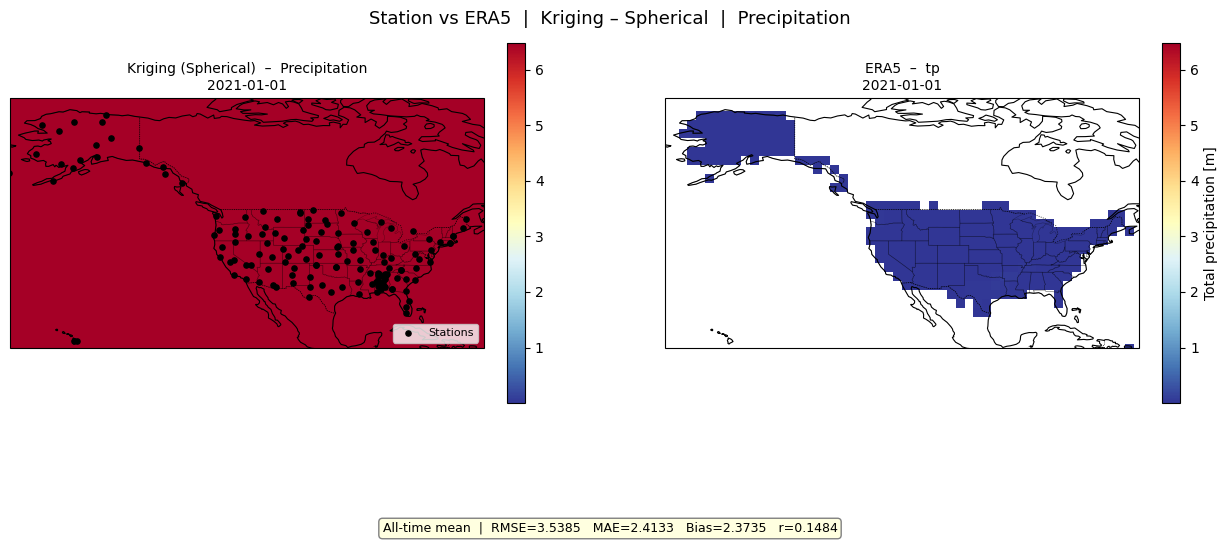

  RMSE=3.5385  MAE=2.4133  Bias=2.3735  r=0.1484
═══ Model: EXPONENTIAL ═══════════════════════════════════
  Computing metrics for model: exponential
  Interpolated NetCDF saved → Precipitation_interpolated_results\interpolated_kriging_exponential.nc
  Plot saved → Precipitation_interpolated_results\plot_kriging_exponential_2021-01-01.png


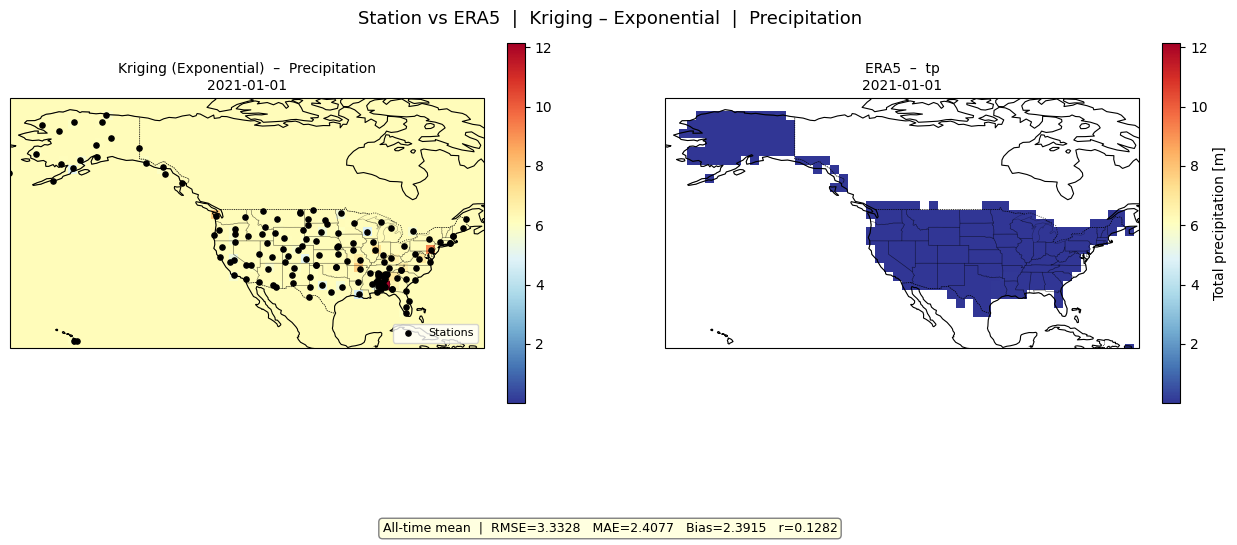

  RMSE=3.3328  MAE=2.4077  Bias=2.3915  r=0.1282
═══ Model: GAUSSIAN ═══════════════════════════════════
  Computing metrics for model: gaussian
  Interpolated NetCDF saved → Precipitation_interpolated_results\interpolated_kriging_gaussian.nc
  Plot saved → Precipitation_interpolated_results\plot_kriging_gaussian_2021-01-01.png


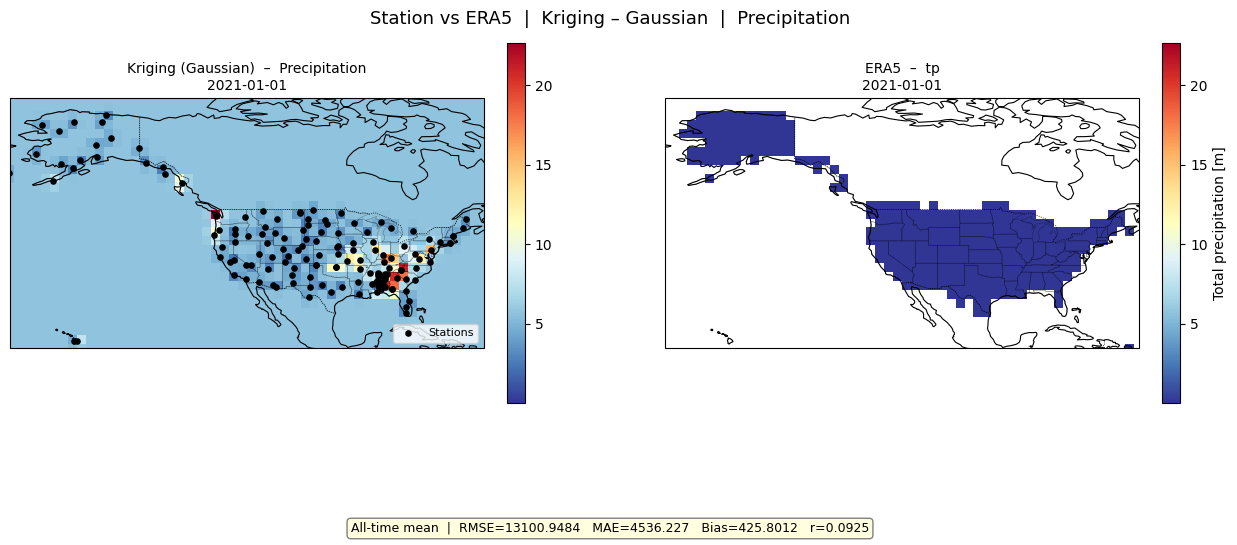

  RMSE=13100.9484  MAE=4536.2270  Bias=425.8012  r=0.0925

── Kriging Summary (all-time means) ──────────────────

                   RMSE        MAE      Bias  Pearson_r
model                                                  
linear           2.7289     2.4108    2.4039     0.1550
spherical        3.5385     2.4133    2.3735     0.1484
exponential      3.3328     2.4077    2.3915     0.1282
gaussian     13100.9484  4536.2270  425.8012     0.0925
Summary saved → Precipitation_interpolated_results\kriging_summary.csv


In [ ]:
pipe = StationInterpolationPipeline(
    excel_path   = r"output_files\processed_USCRN_Precipitation_2006_2021.xlsx",
    lat_col      = "Lat",
    lon_col      = "Lon",
    value_col    = "Precipitation",
    date_col     = "date",
    era5_nc_path = r"era5_total_ppt\era5_clipped.nc",
    era5_var     = "tp",
    output_dir   = "Precipitation_interpolated_results",
    plot_date    = "2021-01-01",  
)

summary = pipe.run_all()

# Soil Temperature

Loading station data …
Loading ERA5 …
plot_date not set → using first shared date: 2006-01-01
Unique_stations=143  |  Shared dates=5844  (2006-01-01 → 2021-12-31)
═══ Model: LINEAR ═══════════════════════════════════
  Computing metrics for model: linear
  Interpolated NetCDF saved → SoilTemp_interpolated_results\interpolated_kriging_linear.nc
  Plot saved → SoilTemp_interpolated_results\plot_kriging_linear_2006-01-01.png


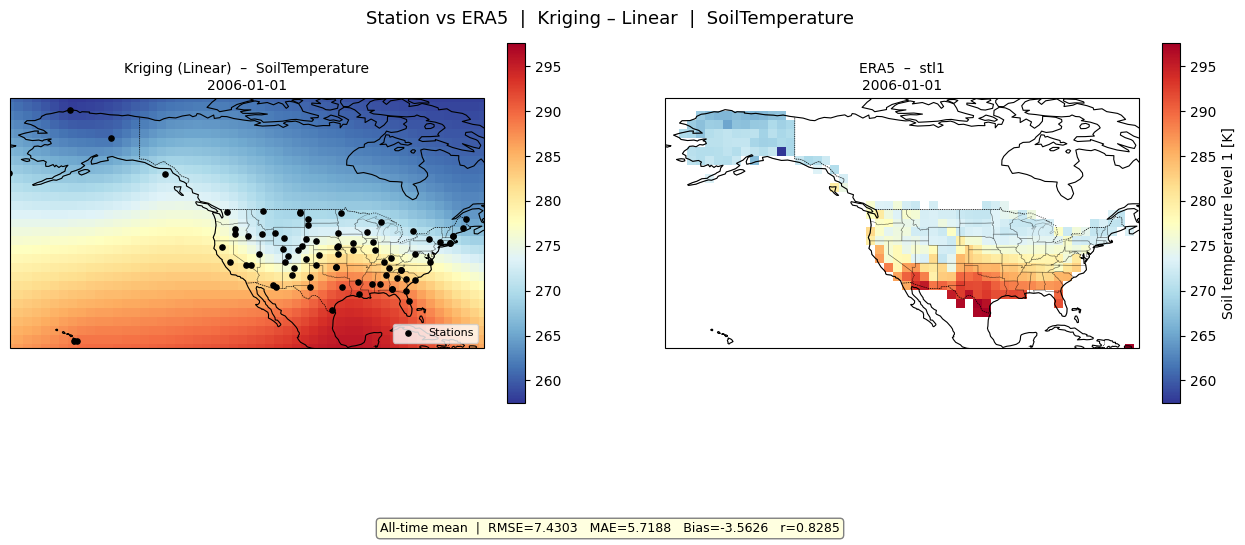

  RMSE=7.4303  MAE=5.7188  Bias=-3.5626  r=0.8285
═══ Model: SPHERICAL ═══════════════════════════════════
  Computing metrics for model: spherical
  Interpolated NetCDF saved → SoilTemp_interpolated_results\interpolated_kriging_spherical.nc
  Plot saved → SoilTemp_interpolated_results\plot_kriging_spherical_2006-01-01.png


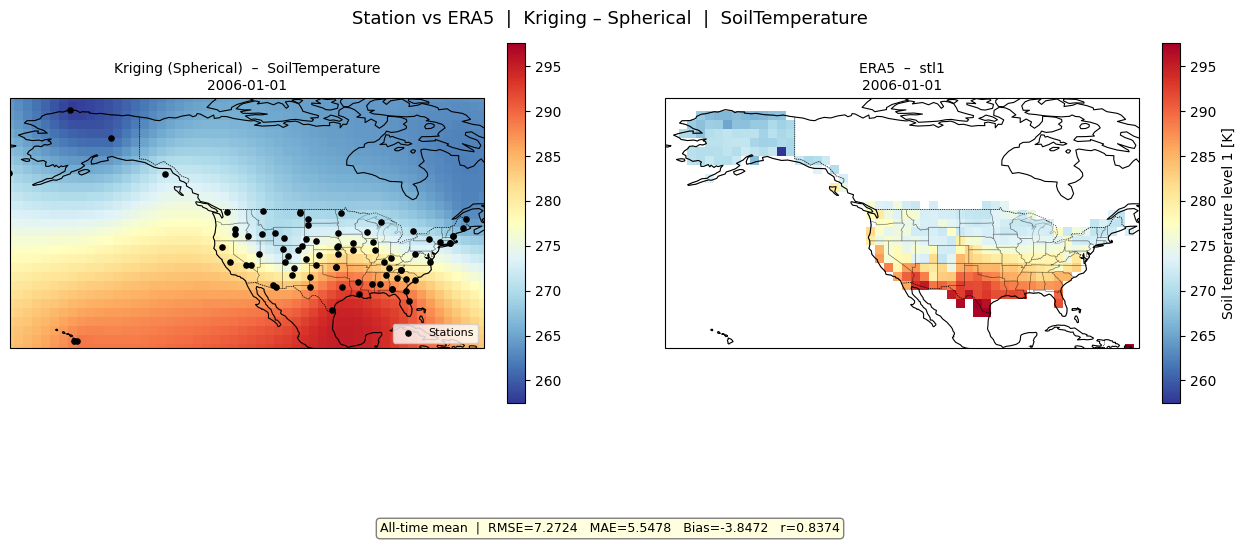

  RMSE=7.2724  MAE=5.5478  Bias=-3.8472  r=0.8374
═══ Model: EXPONENTIAL ═══════════════════════════════════
  Computing metrics for model: exponential
  Interpolated NetCDF saved → SoilTemp_interpolated_results\interpolated_kriging_exponential.nc
  Plot saved → SoilTemp_interpolated_results\plot_kriging_exponential_2006-01-01.png


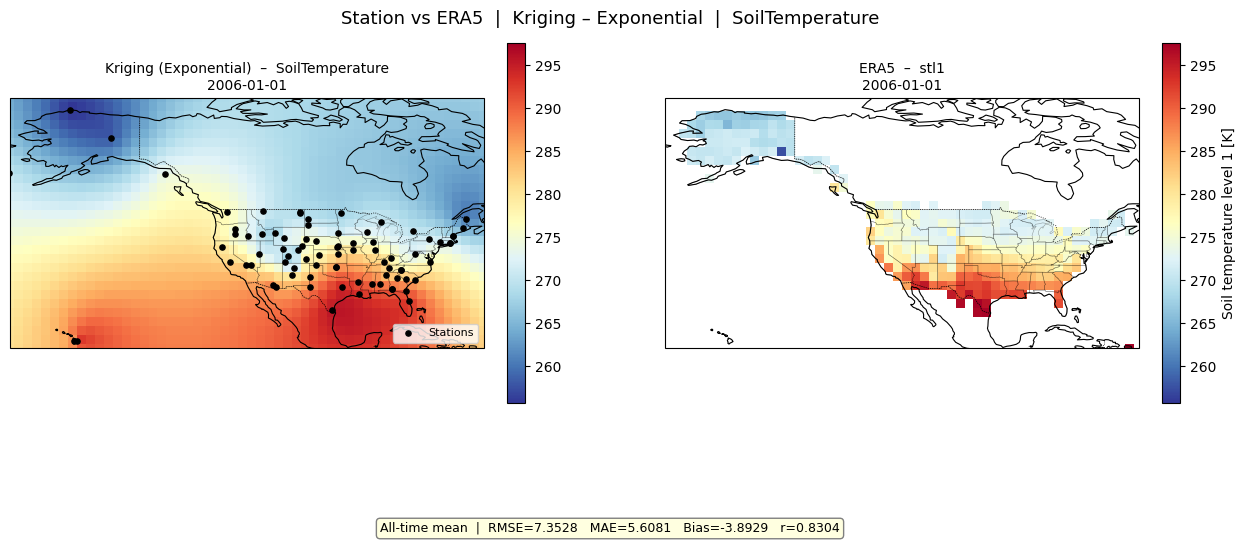

  RMSE=7.3528  MAE=5.6081  Bias=-3.8929  r=0.8304
═══ Model: GAUSSIAN ═══════════════════════════════════
  Computing metrics for model: gaussian
  Interpolated NetCDF saved → SoilTemp_interpolated_results\interpolated_kriging_gaussian.nc
  Plot saved → SoilTemp_interpolated_results\plot_kriging_gaussian_2006-01-01.png


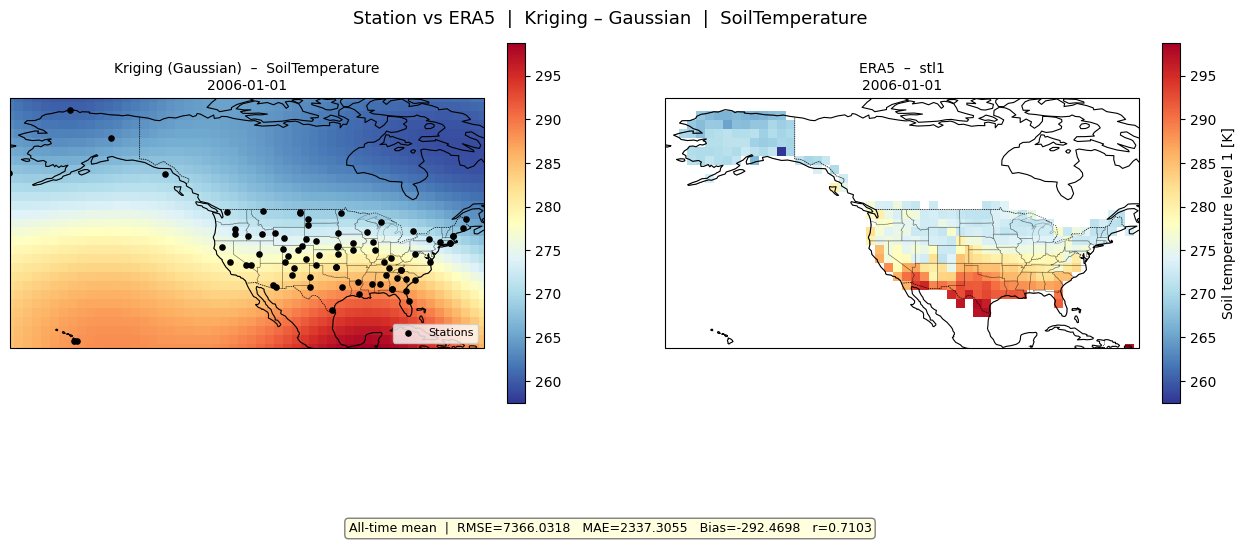

  RMSE=7366.0318  MAE=2337.3055  Bias=-292.4698  r=0.7103

── Kriging Summary (all-time means) ──────────────────

                  RMSE        MAE      Bias  Pearson_r
model                                                 
linear          7.4303     5.7188   -3.5626     0.8285
spherical       7.2724     5.5478   -3.8472     0.8374
exponential     7.3528     5.6081   -3.8929     0.8304
gaussian     7366.0318  2337.3055 -292.4698     0.7103
Summary saved → SoilTemp_interpolated_results\kriging_summary.csv


In [6]:
pipe = StationInterpolationPipeline(
    excel_path   = r"output_files\processed_USCRN_SoilTemperature_2006_2021.xlsx",
    lat_col      = "Lat",
    lon_col      = "Lon",
    value_col    = "SoilTemperature",
    date_col     = "date",
    era5_nc_path = r"era5_soil_temperature\era5_clipped.nc",
    era5_var     = "stl1",
    output_dir   = "SoilTemp_interpolated_results", 
)

summary = pipe.run_all()

# Soil Moisture

In [1]:
import os
import warnings
import logging

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from pykrige.ok import OrdinaryKriging

warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
)
log = logging.getLogger("StationPipeline")

KRIGING_MODELS = ["linear", "spherical", "exponential", "gaussian"]

class StationInterpolationPipeline:
    def __init__(
        self,
        excel_path: str,
        lat_col: str,
        lon_col: str,
        value_col: str,
        date_col: str,
        era5_nc_path: str,
        era5_var: str,
        output_dir: str = "station_output",
        plot_date: str = None,
    ):
        self.excel_path = excel_path
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.value_col = value_col
        self.date_col = date_col
        self.era5_nc_path = era5_nc_path
        self.era5_var = era5_var
        self.output_dir = output_dir
        self.plot_date = plot_date

        os.makedirs(output_dir, exist_ok=True)

        self.df = None
        self.era5_ds = None
        self.lat_grid = None
        self.lon_grid = None
        self.GRID_LON = None
        self.GRID_LAT = None
        self.shared_dates = None

    def load_data(self):
        """Load data and identify the best date for visualization."""
        log.info("Loading station data ...")
        self.df = pd.read_excel(self.excel_path)
        self.df[self.date_col] = pd.to_datetime(self.df[self.date_col])
        self.df = self.df.dropna(subset=[self.lat_col, self.lon_col, self.value_col, self.date_col])

        log.info("Loading ERA5 ...")
        self.era5_ds = xr.open_dataset(self.era5_nc_path, chunks={"time": 30})
        self.lat_grid = self.era5_ds["lat"].values
        self.lon_grid = self.era5_ds["lon"].values
        self.GRID_LON, self.GRID_LAT = np.meshgrid(self.lon_grid, self.lat_grid)

        station_dates = set(self.df[self.date_col].dt.normalize().unique())
        era5_dates = set(pd.to_datetime(self.era5_ds["time"].values).normalize())
        self.shared_dates = sorted(list(station_dates & era5_dates))

        if not self.shared_dates:
            raise ValueError("No overlapping dates found.")

        # Resolve plot_date: Find first date with >= 3 stations
        if self.plot_date is None:
            for d in self.shared_dates:
                count = len(self.df[self.df[self.date_col].dt.normalize() == d])
                if count >= 3:
                    self.plot_date = d
                    log.info(f"Selected best plot_date: {d.date()} ({count} stations)")
                    break
            if self.plot_date is None:
                self.plot_date = self.shared_dates[0]
        else:
            self.plot_date = pd.Timestamp(self.plot_date).normalize()

        log.info(f"Unique stations: {len(self.df[[self.lat_col, self.lon_col]].drop_duplicates())}")

    def _kriging_one_date(self, date: pd.Timestamp, model: str) -> np.ndarray:
        df_day = self.df[self.df[self.date_col].dt.normalize() == date.normalize()]
        if len(df_day) < 3:
            return np.full(self.GRID_LON.shape, np.nan)

        try:
            OK = OrdinaryKriging(
                df_day[self.lon_col].values,
                df_day[self.lat_col].values,
                df_day[self.value_col].values,
                variogram_model=model,
                verbose=False,
                enable_plotting=False,
            )
            grid_vals, _ = OK.execute("grid", self.lon_grid, self.lat_grid)
            return np.array(grid_vals)
        except Exception:
            return np.full(self.GRID_LON.shape, np.nan)

    def _compute_metrics(self, model: str) -> dict:
        log.info(f" Computing metrics for model: {model}")
        rows, grids, valid_times = [], [], []

        for date in self.shared_dates:
            ts = pd.Timestamp(date)
            station_grid = self._kriging_one_date(ts, model)
            
            if np.all(np.isnan(station_grid)):
                continue

            era5_slice = self.era5_ds[self.era5_var].sel(time=ts, method="nearest").values
            mask = ~(np.isnan(era5_slice) | np.isnan(station_grid))
            
            if mask.sum() > 2:
                e, s = era5_slice[mask], station_grid[mask]
                
                # Check for zero variance to prevent Pearson R errors
                if np.std(e) == 0 or np.std(s) == 0:
                    r = 0.0
                else:
                    r, _ = pearsonr(e, s)

                rows.append({
                    "RMSE": float(np.sqrt(mean_squared_error(e, s))),
                    "MAE": float(np.mean(np.abs(e - s))),
                    "Bias": float(np.mean(s - e)),
                    "Pearson_r": float(r),
                })
                grids.append(station_grid)
                valid_times.append(ts)

        if not grids:
            log.error(f" No valid data for model {model}")
            return {"RMSE": 0, "MAE": 0, "Bias": 0, "Pearson_r": 0, "model": model}

        # Save NetCDF
        interp_da = xr.DataArray(
            np.stack(grids),
            dims=["time", "lat", "lon"],
            coords={"time": valid_times, "lat": self.lat_grid, "lon": self.lon_grid},
            name=self.value_col
        )
        nc_path = os.path.join(self.output_dir, f"interpolated_kriging_{model}.nc")
        interp_da.to_netcdf(nc_path)
        
        df_m = pd.DataFrame(rows)
        means = df_m.mean().round(4).to_dict()
        means["model"] = model
        return means

    def _plot(self, model: str, mean_metrics: dict):
        ts = pd.Timestamp(self.plot_date)
        station_grid = self._kriging_one_date(ts, model)
        
        if np.all(np.isnan(station_grid)):
            log.warning(f" Skipping plot for {model}: No valid data on {ts.date()}")
            return

        era5_slice = self.era5_ds[self.era5_var].sel(time=ts, method="nearest")
        
        vmin = min(np.nanmin(station_grid), float(era5_slice.min()))
        vmax = max(np.nanmax(station_grid), float(era5_slice.max()))

        fig = plt.figure(figsize=(16, 7))
        gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.15)
        proj = ccrs.PlateCarree()

        data_to_plot = [
            (station_grid, f"Kriging ({model.capitalize()})\n{ts.date()}"),
            (era5_slice.values, f"ERA5 ({self.era5_var})\n{ts.date()}")
        ]

        for idx, (data, title) in enumerate(data_to_plot):
            ax = fig.add_subplot(gs[idx], projection=proj)
            im = ax.pcolormesh(self.lon_grid, self.lat_grid, data, 
                               cmap="RdYlBu_r", vmin=vmin, vmax=vmax, transform=proj)
            plt.colorbar(im, ax=ax, shrink=0.6)
            
            ax.add_feature(cfeature.COASTLINE)
            ax.add_feature(cfeature.BORDERS, linestyle=':')
            ax.set_title(title)
            
            if idx == 0:
                df_day = self.df[self.df[self.date_col].dt.normalize() == ts.normalize()]
                ax.scatter(df_day[self.lon_col], df_day[self.lat_col], c="black", s=10, transform=proj)

        footer = f"Mean Metrics: RMSE={mean_metrics['RMSE']} | MAE={mean_metrics['MAE']} | r={mean_metrics['Pearson_r']}"
        fig.text(0.5, 0.05, footer, ha="center", bbox=dict(facecolor='white', alpha=0.5))
        
        plt.savefig(os.path.join(self.output_dir, f"plot_{model}_{ts.date()}.png"), dpi=150, bbox_inches="tight")
        plt.show()

    def run_all(self):
        self.load_data()
        summary_rows = []
        for model in KRIGING_MODELS:
            log.info(f"=== Process Model: {model.upper()} ===")
            means = self._compute_metrics(model)
            self._plot(model, means)
            summary_rows.append(means)

        summary_df = pd.DataFrame(summary_rows).set_index("model")
        summary_df.to_csv(os.path.join(self.output_dir, "summary.csv"))
        log.info("\nFinal Summary:\n%s", summary_df.to_string())
        return summary_df

Loading station data ...


Loading ERA5 ...
Unique stations: 115
=== Process Model: LINEAR ===
 Computing metrics for model: linear


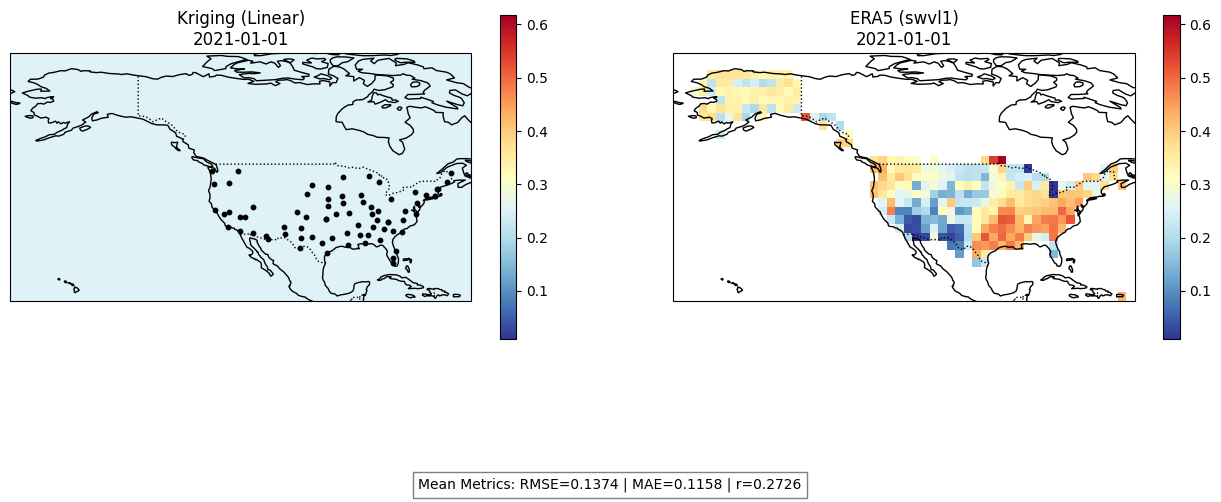

=== Process Model: SPHERICAL ===
 Computing metrics for model: spherical


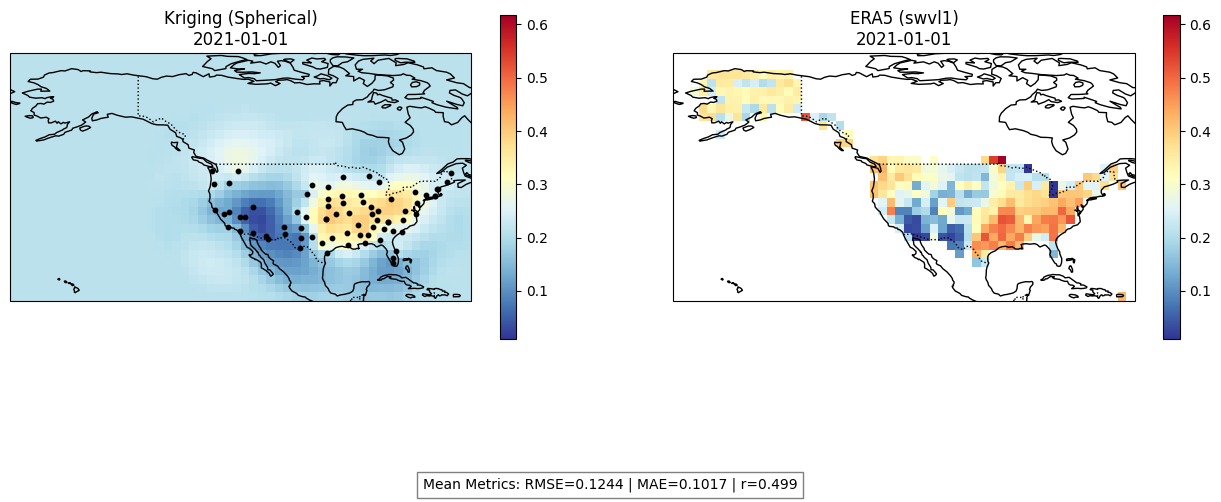

=== Process Model: EXPONENTIAL ===
 Computing metrics for model: exponential


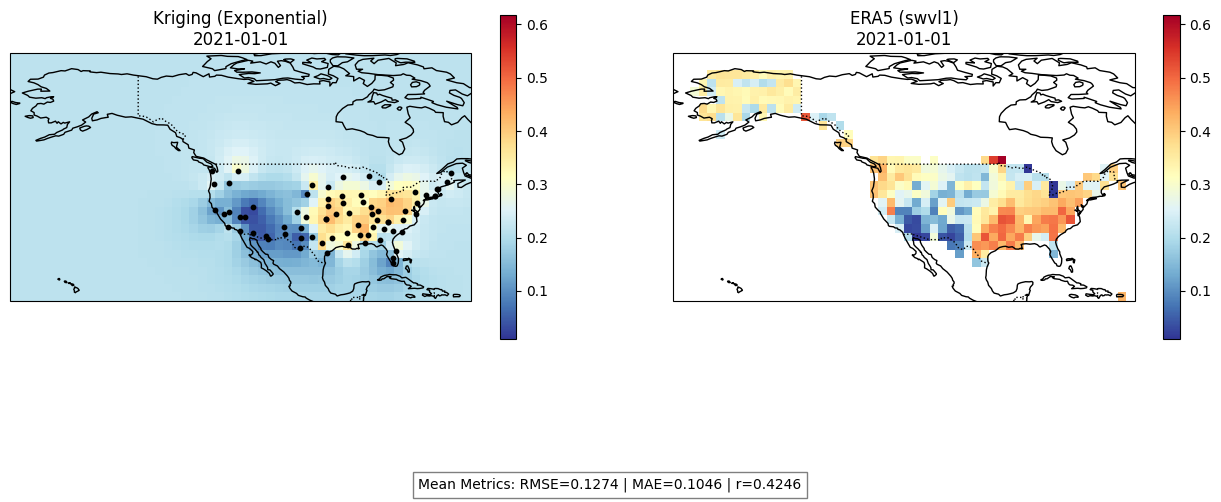

=== Process Model: GAUSSIAN ===
 Computing metrics for model: gaussian


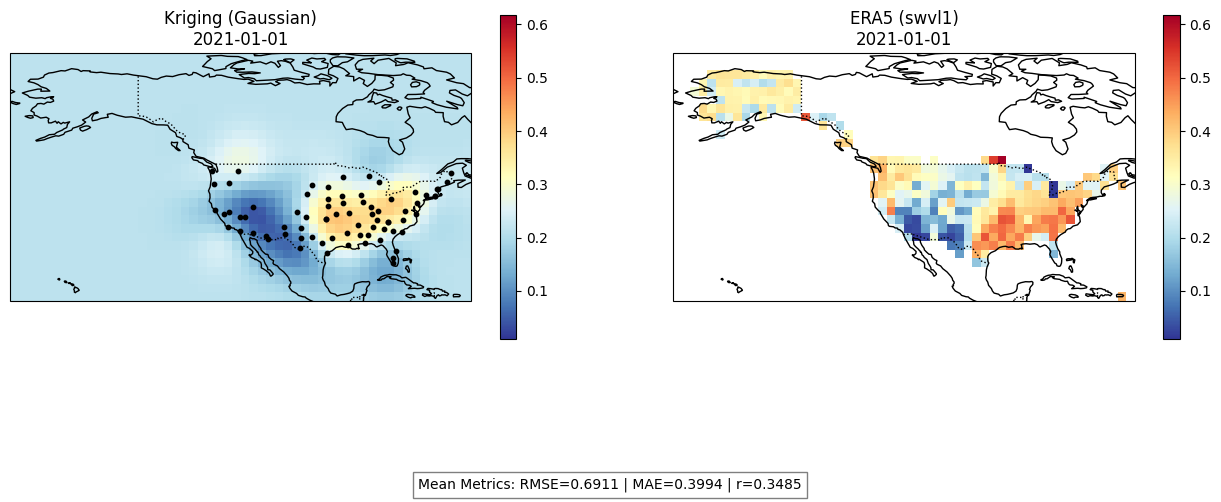


Final Summary:
               RMSE     MAE    Bias  Pearson_r
model                                         
linear       0.1374  0.1158 -0.0677     0.2726
spherical    0.1244  0.1017 -0.0675     0.4990
exponential  0.1274  0.1046 -0.0669     0.4246
gaussian     0.6911  0.3994 -0.1863     0.3485


In [4]:
pipe = StationInterpolationPipeline(
    excel_path   = r"output_files\processed_USCRN_SoilMoisture10cm_2006_2021.xlsx",
    lat_col      = "Lat",
    lon_col      = "Lon",
    value_col    = "SoilMoisture10cm",
    date_col     = "date",
    era5_nc_path = r"era5_soil_moisture\era5_clipped.nc",
    era5_var     = "swvl1",
    output_dir   = "SoilMoist_interpolated_results", 
    plot_date    = "2021-01-01",
)

summary = pipe.run_all()

# RH

Loading station data ...
Loading ERA5 ...
Unique stations: 142
=== Process Model: LINEAR ===
 Computing metrics for model: linear


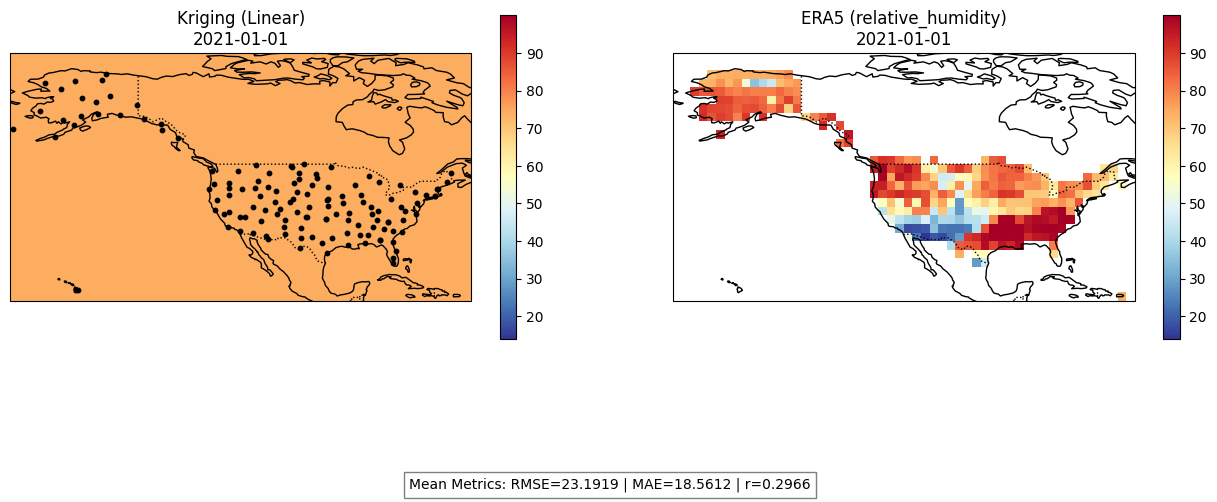

=== Process Model: SPHERICAL ===
 Computing metrics for model: spherical


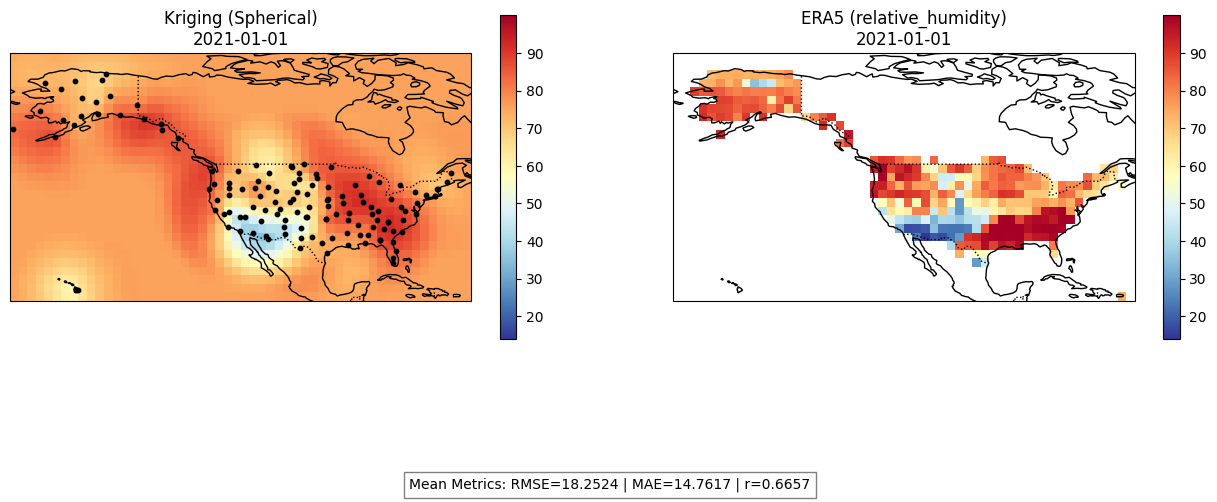

=== Process Model: EXPONENTIAL ===
 Computing metrics for model: exponential


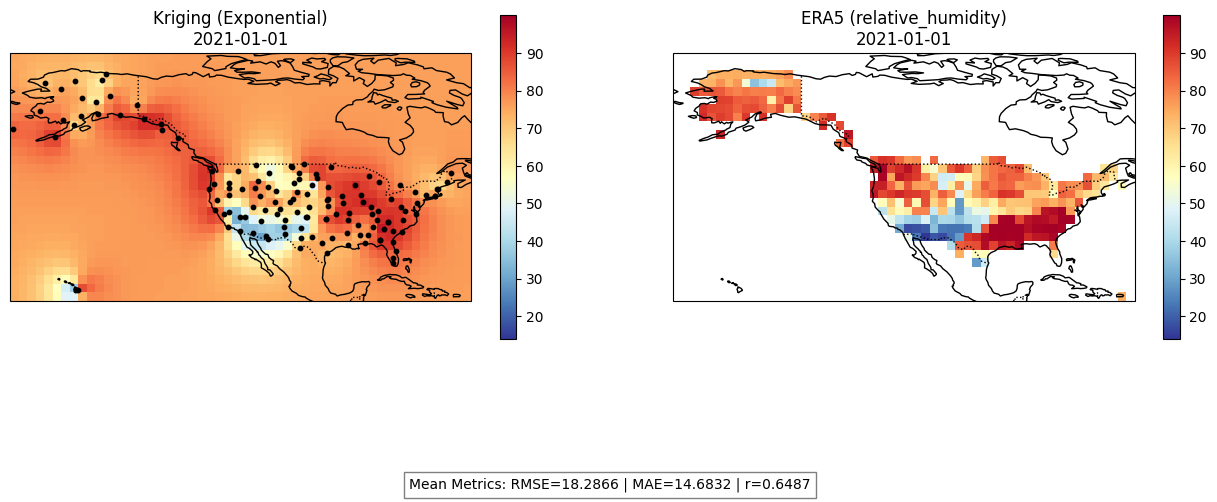

=== Process Model: GAUSSIAN ===
 Computing metrics for model: gaussian


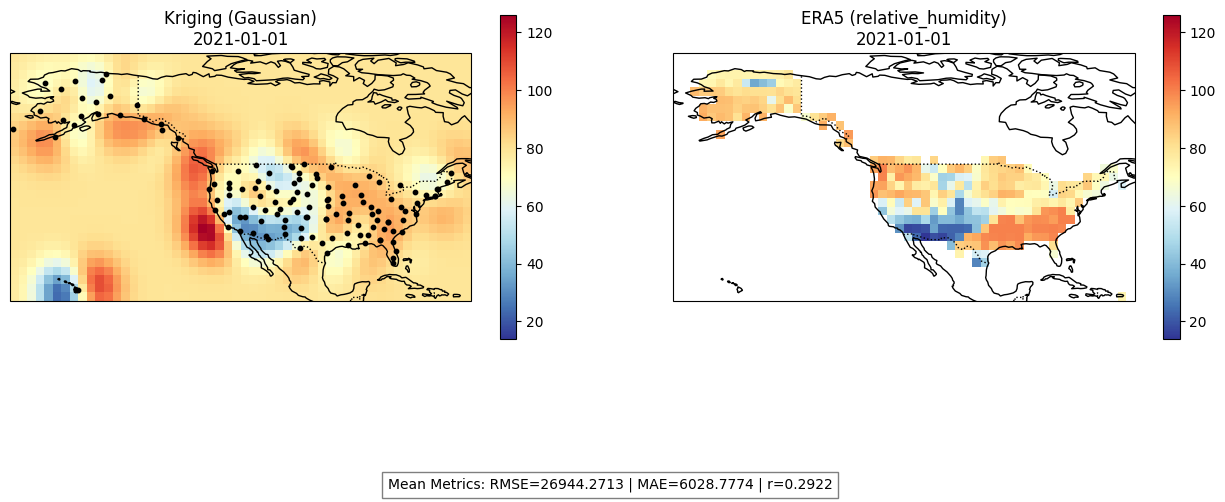


Final Summary:
                   RMSE        MAE       Bias  Pearson_r
model                                                   
linear          23.1919    18.5612     7.9261     0.2966
spherical       18.2524    14.7617     8.2078     0.6657
exponential     18.2866    14.6832     8.0699     0.6487
gaussian     26944.2713  6028.7774 -2585.7494     0.2922


In [ ]:
pipe = StationInterpolationPipeline(
    excel_path   = r"output_files\processed_USCRN_RelativeHumidity_2006_2021.xlsx",
    lat_col      = "Lat",
    lon_col      = "Lon",
    value_col    = "RelativeHumidity",
    date_col     = "date",
    era5_nc_path = r"era5_relative_humidity.nc",
    era5_var     = "relative_humidity",
    output_dir   = "relativehumidity_interpolated_results", 
    plot_date    = "2021-01-01",
)

summary = pipe.run_all()